In [ ]:
from pathlib import Path
import os
import sys

_here = Path.cwd().resolve()
_repo_root = next(path for path in (_here, *_here.parents) if (path / "configs" / "cfg.py").exists())
os.chdir(_repo_root)
sys.path.insert(0, str(_repo_root))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

import scripts.compare as compare_module
from utils.run_artifacts import load_experiment_context

cfg, run_dir = load_experiment_context("artifacts/runs/madrl_base_EV_soft_arrival_0p30_penalty_1000")
run_dir = Path(run_dir)

# EV soft-constraint configuration
cfg.env.ev_enabled = True
cfg.model.action_dim = 3
cfg.env.ev_capacity_kwh = (60.0, 60.0, 60.0)
cfg.env.ev_soc_min = 0.10
cfg.env.ev_soc_max = 0.95
cfg.env.ev_arrival_soc = 0.15
cfg.env.ev_departure_soc_req = 0.90
cfg.env.ev_max_charge_kw = (11.0, 11.0, 11.0)
cfg.env.ev_efficiency = 0.95
cfg.env.ev_arrival_step = 72
cfg.env.ev_departure_step = 28
cfg.reward.ev_departure_penalty_weight = 500.0
cfg.reward.ev_soc_regularization_weight = 0.005

display(Markdown("# Compare + EV Soft Constraint"))
display(pd.DataFrame([{
    "run_dir": str(run_dir),
    "ev_enabled": bool(cfg.env.ev_enabled),
    "action_dim": int(cfg.model.action_dim),
    "ev_capacity_kwh": cfg.env.ev_capacity_kwh,
    "ev_arrival_soc": float(cfg.env.ev_arrival_soc),
    "ev_departure_soc_req": float(cfg.env.ev_departure_soc_req),
    "ev_max_charge_kw": cfg.env.ev_max_charge_kw,
    "ev_arrival_step": int(cfg.env.ev_arrival_step),
    "ev_departure_step": int(cfg.env.ev_departure_step),
    "ev_departure_penalty_weight": float(cfg.reward.ev_departure_penalty_weight),
}]))

available_schemes = []
for mode, controller in compare_module.COMPARE_SCHEMES:
    step_path = run_dir / "results" / mode / controller / "record" / "step.parquet"
    if not step_path.exists():
        print(f"Skip missing result: {mode}/{controller}")
        continue
    try:
        columns = pd.read_parquet(step_path, engine="pyarrow").columns
    except Exception as exc:
        print(f"Skip unreadable result: {mode}/{controller}: {exc}")
        continue
    if "ev_charge_total" not in columns:
        print(f"Skip missing result: {mode}/{controller}")
        continue
    available_schemes.append((mode, controller))

if not available_schemes:
    display(Markdown("## No EV soft records found"))
    print("Run the EV soft notebooks under notebooks/notebooks_EV first, and write results to the current run_dir.")
else:
    print("EV soft results included in compare:")
    for mode, controller in available_schemes:
        print(f"- {mode}/{controller}")

    compare_module.COMPARE_SCHEMES = available_schemes
    result = compare_module.compare_records(cfg, run_dir)

    display(result["metrics_df"])
    display(result["economic_table"])
    display(result["safety_table"])

    _plot_specs = [
        ("1. Power balance", "compare_price"),
        ("2. Price", "compare_voltage"),
        ("3. Net load", "compare_net_load"),
        ("4. Battery power and SoC", "compare_battery_soc"),
        ("5. Power balance", "compare_power_balance"),
    ]

    for title, name in _plot_specs:
        print(f"{title} - EV soft constraint")
        if name in result["figures"]:
            display(result["figures"][name])
            plt.close(result["figures"][name])
        else:
            print(f"Figure missing, skipped: {name}")


MADRL Battery Diagnostics
Post-processing only: battery power, SOC, price, and optional raw/projected action checks.

In [ ]:
from pathlib import Path
from IPython.display import Image, display, Markdown
import importlib
import scripts.madrl_battery_diagnostics as battery_diag_module
battery_diag_module = importlib.reload(battery_diag_module)
plot_madrl_training_convergence = battery_diag_module.plot_madrl_training_convergence
run_madrl_battery_diagnostics = battery_diag_module.run_madrl_battery_diagnostics

# Change these two lines to inspect another run/model variant.
diagnostic_run_dir = Path("artifacts/runs/madrl_base_EV_soft_arrival_0p30_penalty_1000")
diagnostic_scheme_name = "madrl_base_EV_soft"

SCHEME_TO_RECORD = {
    "madrl_base_EV_soft": ("madrl_base", "MADRL_BASE"),
    "madrl_base_safe_EV_soft": ("madrl_base_safe", "MADRL_PENALTY"),
    "madrl_projection_safe_EV_soft": ("madrl_projection_safe", "MADRL_PROJECTION"),

    "madrl_base_EV_soft_costweight": ("madrl_base_EV_soft_costweight", "MADRL_BASE_COSTWEIGHT"),
    "madrl_base_EV_hard": ("madrl_base_EV_hard", "MADRL_BASE_EV_HARD"),
    "madrl_base_EV_soft_progress": ("madrl_base_EV_soft_progress", "MADRL_BASE_PROGRESS"),
}

record_scheme_name, diagnostic_controller = SCHEME_TO_RECORD.get(
    diagnostic_scheme_name,
    (diagnostic_scheme_name, "MADRL_BASE"),
)

battery_diag = run_madrl_battery_diagnostics(
    diagnostic_run_dir,
    forecast_mode="lstm",
    controller=diagnostic_controller,
    scheme_name=record_scheme_name,
    include_action_trace=True,
)
tables = battery_diag["report_tables"]

display(Markdown(f"# Battery diagnosis: `{diagnostic_scheme_name}`"))
display(Markdown(f"Run dir: `{diagnostic_run_dir}`"))

display(Markdown("## 1. Training setup"))
display(tables["train_overview"])

display(Markdown("## 2. Overall rollout effect"))
display(tables["rollout_effect"])

display(Markdown("## 3. Battery price dispatch"))
display(tables["battery_price_dispatch"])

display(Markdown("## 4. Per-agent battery diagnosis"))
display(tables["by_agent_battery"])

display(Markdown("## 5. EV behavior and battery interaction"))
display(tables["ev_behavior"])

if "ev_overcharge_diagnostics" in tables:
    display(Markdown("## 6. EV overcharge diagnostics"))
    display(tables["ev_overcharge_diagnostics"])

display(Markdown("## 7. SOC limit diagnosis"))
display(tables["soc_limits"])

display(Markdown("## 8. Reward scale"))
display(tables["reward_scale"])

display(Markdown("## 9. Cumulative cost breakdown"))
display(tables["cumulative_cost_breakdown"])

if "cumulative_cost_timeseries" in tables and not tables["cumulative_cost_timeseries"].empty:
    last_cost = tables["cumulative_cost_timeseries"].iloc[-1]
    display(Markdown(
        f"Final cumulative battery cost: `{last_cost['cumulative_battery_cost_eur']:.4f}` EUR; "
        f"EV cost: `{last_cost['cumulative_ev_cost_eur']:.4f}` EUR; "
        f"battery + EV total: `{last_cost['cumulative_total_cost_eur']:.4f}` EUR."
    ))

display(Markdown("## Learning curve windows"))
display(tables["learning_windows"])

display(Markdown("## Training convergence curve"))
convergence = plot_madrl_training_convergence(
    diagnostic_run_dir,
    scheme_name=record_scheme_name,
    rolling_window=10,
    tail_window=20,
)
display(convergence["summary"])
display(Image(filename=str(convergence["figure"])))

display(Markdown("## Agent battery power + SOC + price figures"))
for agent, path in battery_diag["figures"].items():
    print(agent, path)
    display(Image(filename=str(path)))

display(Markdown("## Agent EV charging + SOC + price figures (18:00-07:00 only)"))
for agent, path in battery_diag.get("ev_figures", {}).items():
    print(agent, path)
    display(Image(filename=str(path)))

warning = battery_diag["manifest"].get("action_trace_warning")
if warning:
    print(warning)
else:
    display(Markdown("## Raw vs projected battery action"))
    display(battery_diag["action_trace"].head())
    print("Action trace saved to:", battery_diag["manifest"]["action_trace_csv"])

print("Saved report tables to:", battery_diag["manifest"]["report_dir"])


Battery and EV comparison

# EV batch comparison: `madrl_projection_safe_EV_hard_Continuous_new`

## 1-3. Calendar-day total cost, EV charging cost, battery cost (00:00-24:00)

,scheme,controller,type,total_cost_eur,ev_charging_cost_all_agents_eur,battery_cost_all_agents_eur,total_ev_charge_requested_kwh,total_ev_charge_executed_kwh,total_ev_charge_clipped_kwh,ev_charging_cost_agent_0_eur,battery_cost_agent_0_eur,ev_charging_cost_agent_1_eur,battery_cost_agent_1_eur,ev_charging_cost_agent_2_eur,battery_cost_agent_2_eur
0,MADRL Projection EV Hard Continuous_new,MADRL_PROJECTION_EV_HARD_Continuous_new,hard,494.246773,288.424693,205.822080,3926.122597,1784.408220,2141.714377,104.466673,64.754771,99.596460,189.559602,84.361559,-48.492292
1,Local MPC + LSTM Forecast + EV Hard Constraint,local_mpc_lstm_EV_hard,hard,-36.374254,235.681183,-272.055442,1705.263031,1705.263031,0.000000,78.560394,-89.998173,78.560394,-90.963713,78.560394,-91.093556
2,ADMM MPC + LSTM Forecast + EV Hard Constraint,admm_mpc_lstm_EV_hard,hard,-2.855116,235.744097,-238.599211,1705.273642,1705.273642,0.000000,78.581362,-79.533159,78.581366,-79.532935,78.581369,-79.533117


## 3b. EV session cost summary (18:00-07:00, complete parking sessions only)

,scheme,controller,type,agent_id,session_count,ev_session_energy_total_kwh,ev_session_energy_mean_kwh,ev_session_cost_total_eur,ev_session_cost_mean_eur,departure_soc_mean,departure_soc_min,departure_gap_mean,departure_gap_max,theoretical_minimum_energy_per_session_kwh,theoretical_minimum_energy_total_kwh,actual_theoretical_ratio
0,MADRL Projection EV Hard Continuous_new,MADRL_PROJECTION_EV_HARD_Continuous_new,hard,0,14,539.368437,38.526317,96.645502,6.903250,0.910000,0.91,0.0,0.0,37.894737,530.526316,1.016667
1,MADRL Projection EV Hard Continuous_new,MADRL_PROJECTION_EV_HARD_Continuous_new,hard,1,14,539.368480,38.526320,90.335082,6.452506,0.910000,0.91,0.0,0.0,37.894737,530.526316,1.016667
2,MADRL Projection EV Hard Continuous_new,MADRL_PROJECTION_EV_HARD_Continuous_new,hard,2,14,537.473693,38.390978,78.527508,5.609108,0.907857,0.90,0.0,0.0,37.894737,530.526316,1.013095
3,Local MPC + LSTM Forecast + EV Hard Constraint,local_mpc_lstm_EV_hard,hard,0,14,530.526276,37.894734,73.368668,5.240619,0.900000,0.90,0.0,0.0,37.894737,530.526316,1.000000
4,Local MPC + LSTM Forecast + EV Hard Constraint,local_mpc_lstm_EV_hard,hard,1,14,530.526276,37.894734,73.368668,5.240619,0.900000,0.90,0.0,0.0,37.894737,530.526316,1.000000
5,Local MPC + LSTM Forecast + EV Hard Constraint,local_mpc_lstm_EV_hard,hard,2,14,530.526276,37.894734,73.368668,5.240619,0.900000,0.90,0.0,0.0,37.894737,530.526316,1.000000
6,ADMM MPC + LSTM Forecast + EV Hard Constraint,admm_mpc_lstm_EV_hard,hard,0,14,530.529716,37.894980,73.389615,5.242115,0.900000,0.90,0.0,0.0,37.894737,530.526316,1.000006
7,ADMM MPC + LSTM Forecast + EV Hard Constraint,admm_mpc_lstm_EV_hard,hard,1,14,530.529716,37.894980,73.389619,5.242116,0.900000,0.90,0.0,0.0,37.894737,530.526316,1.000006
8,ADMM MPC + LSTM Forecast + EV Hard Constraint,admm_mpc_lstm_EV_hard,hard,2,14,530.529718,37.894980,73.389622,5.242116,0.900000,0.90,0.0,0.0,37.894737,530.526316,1.000006


## 5-6. Price correlation: battery and EV

,scheme,controller,type,agent_id,battery_power_price_corr,battery_avg_price_when_charging,battery_avg_price_when_discharging,ev_charge_price_corr,ev_avg_price_when_charging,ev_charge_mean_kw
0,MADRL Projection EV Hard Continuous_new,MADRL_PROJECTION_EV_HARD_Continuous_new,hard,0,-0.141972,0.138898,0.167566,0.164245,0.184888,1.656357
1,MADRL Projection EV Hard Continuous_new,MADRL_PROJECTION_EV_HARD_Continuous_new,hard,1,-0.036496,0.144763,0.158707,0.098215,0.181969,1.677323
2,MADRL Projection EV Hard Continuous_new,MADRL_PROJECTION_EV_HARD_Continuous_new,hard,2,-0.206338,0.138870,0.163520,-0.044010,0.162303,1.623009
3,Local MPC + LSTM Forecast + EV Hard Constraint,local_mpc_lstm_EV_hard,hard,0,-0.205908,0.074643,0.148903,-0.068087,0.137911,1.578947
4,Local MPC + LSTM Forecast + EV Hard Constraint,local_mpc_lstm_EV_hard,hard,1,-0.207496,0.075131,0.145460,-0.068087,0.137911,1.578947
5,Local MPC + LSTM Forecast + EV Hard Constraint,local_mpc_lstm_EV_hard,hard,2,-0.207143,0.074006,0.142773,-0.068087,0.137911,1.578947
6,ADMM MPC + LSTM Forecast + EV Hard Constraint,admm_mpc_lstm_EV_hard,hard,0,-0.255531,0.087624,0.147847,-0.067919,0.157683,1.578957
7,ADMM MPC + LSTM Forecast + EV Hard Constraint,admm_mpc_lstm_EV_hard,hard,1,-0.255531,0.086425,0.146973,-0.067918,0.157683,1.578957
8,ADMM MPC + LSTM Forecast + EV Hard Constraint,admm_mpc_lstm_EV_hard,hard,2,-0.255531,0.085925,0.147319,-0.067918,0.157683,1.578957


## 7. Battery power, SOC, and price

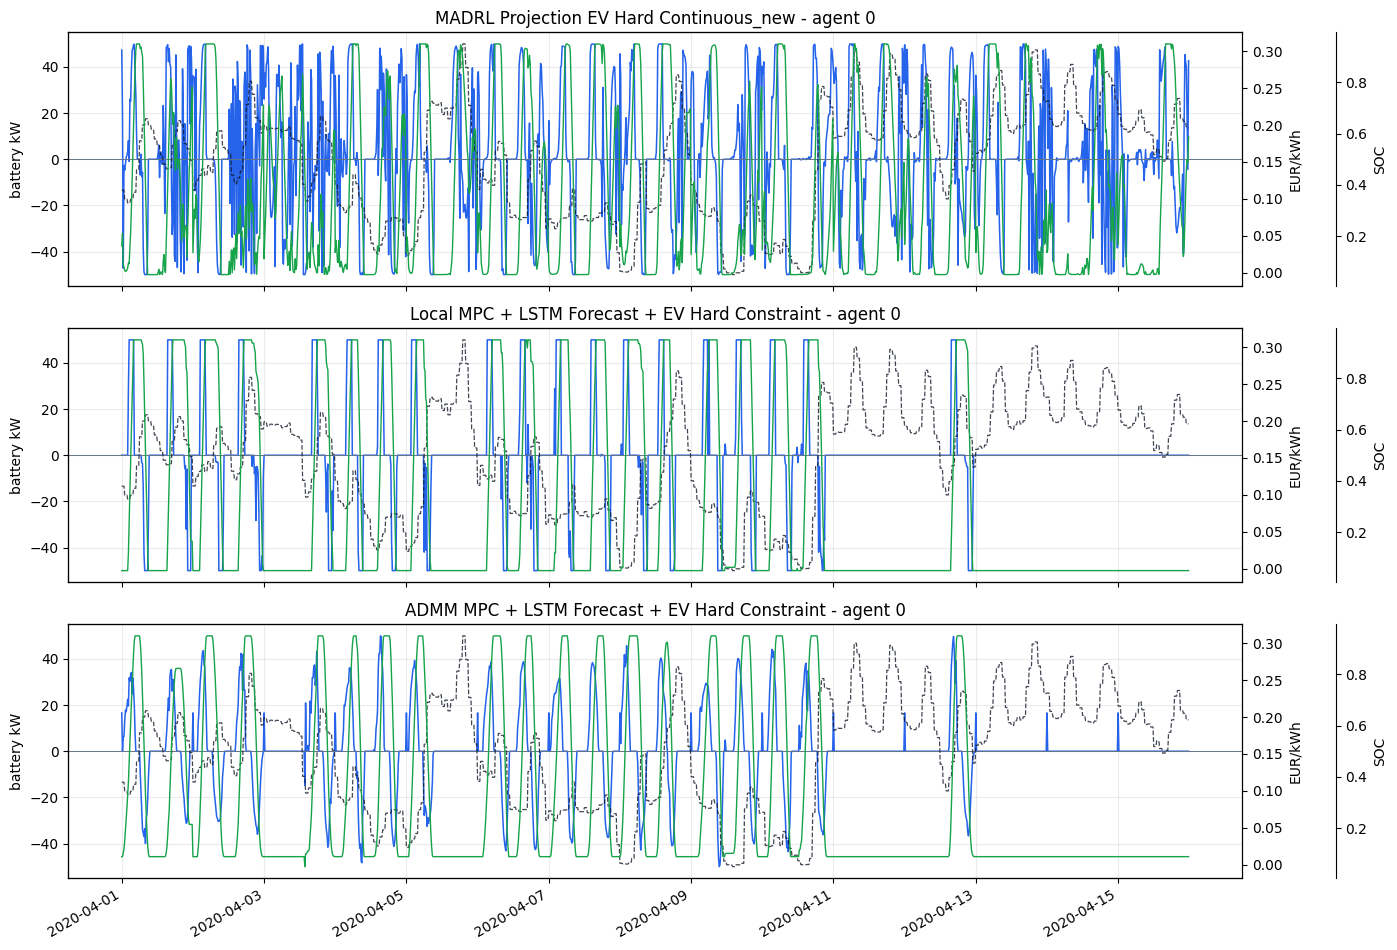

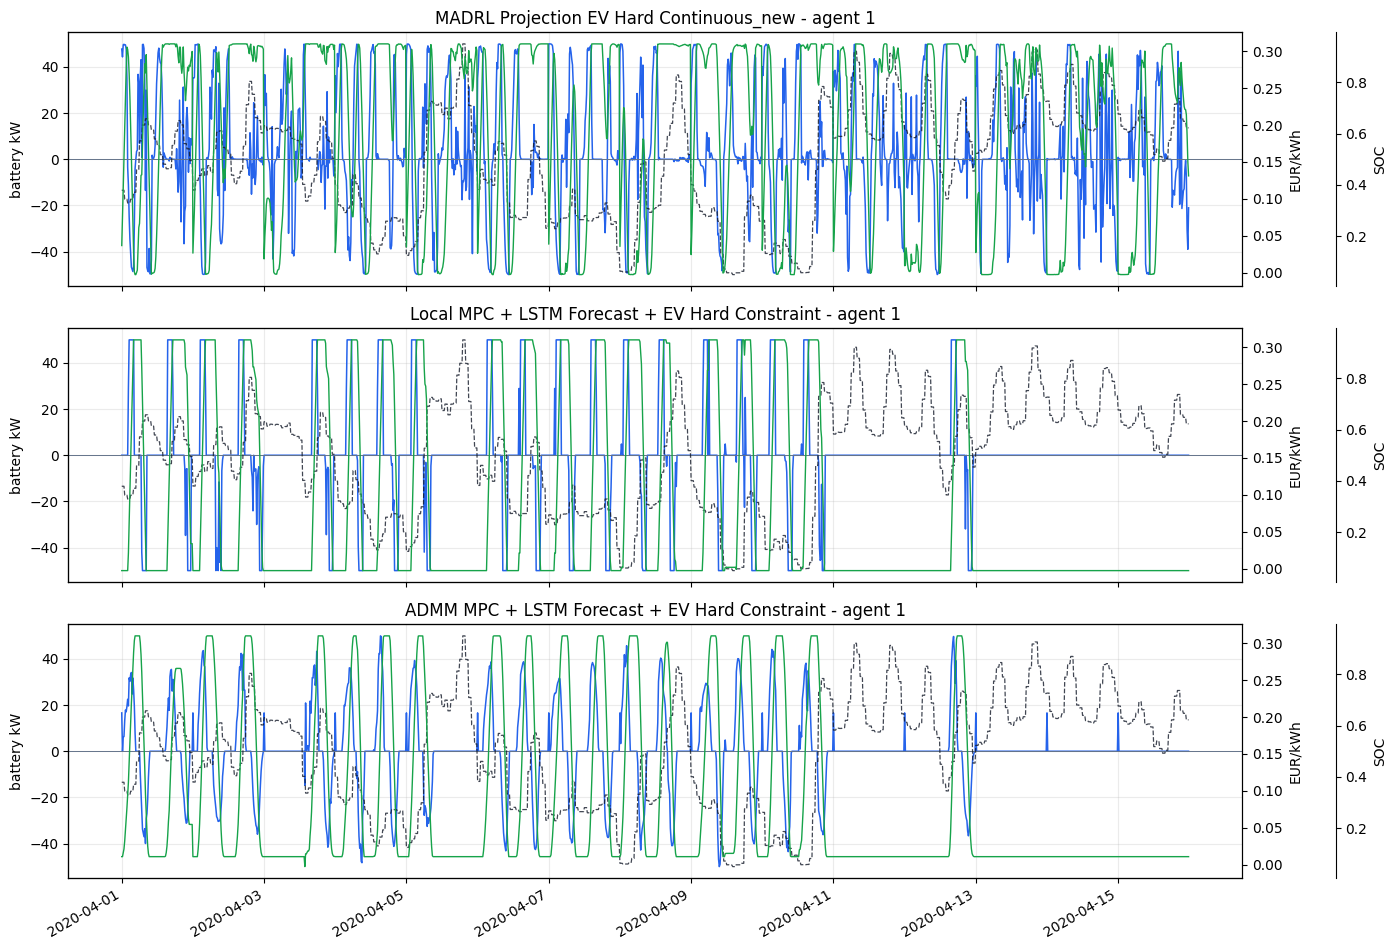

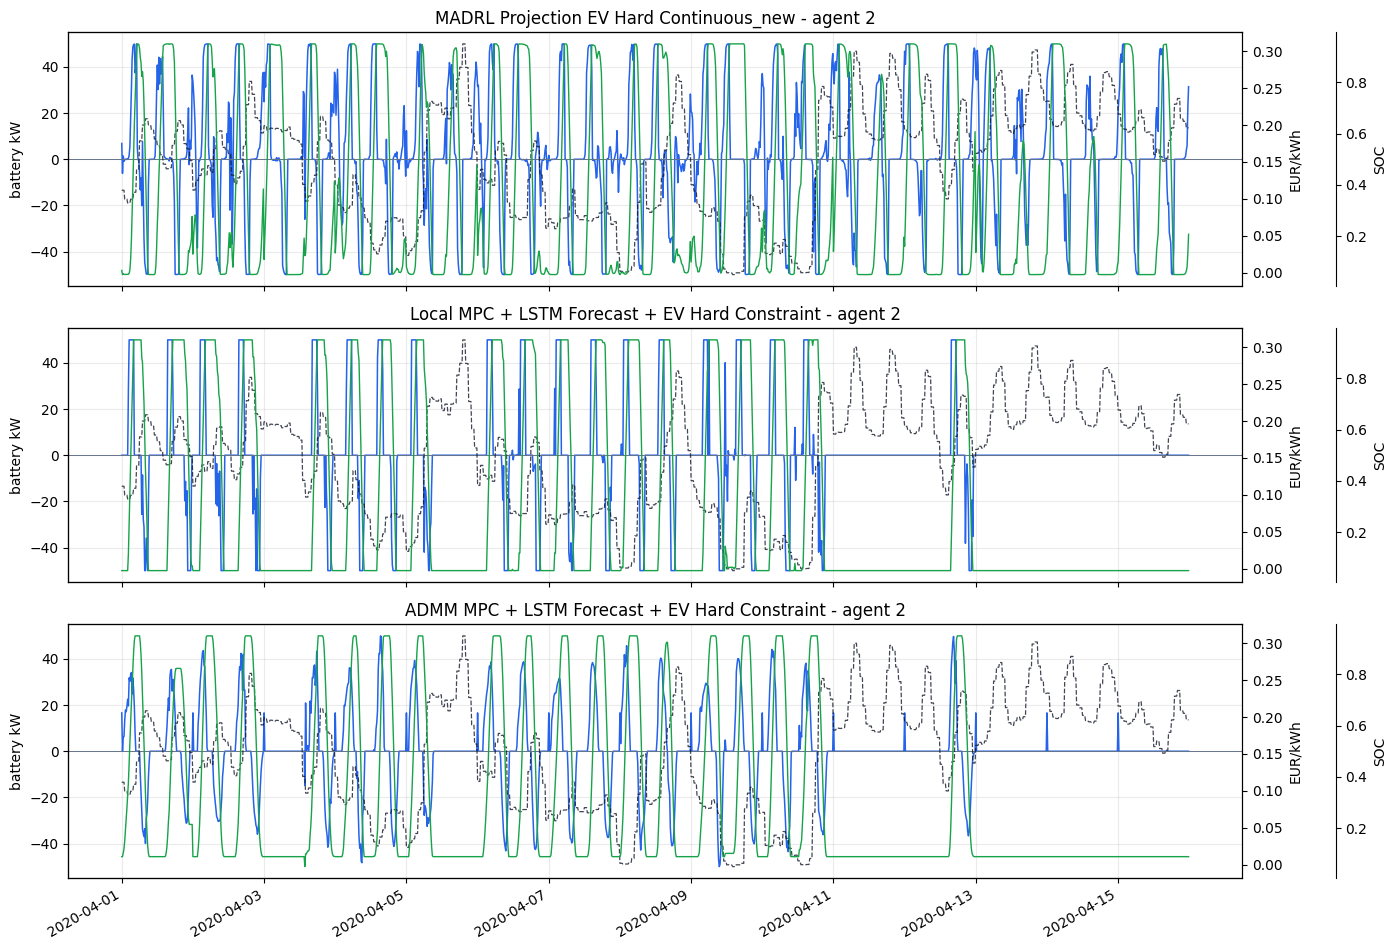

## 8. EV charge power, SOC, and price

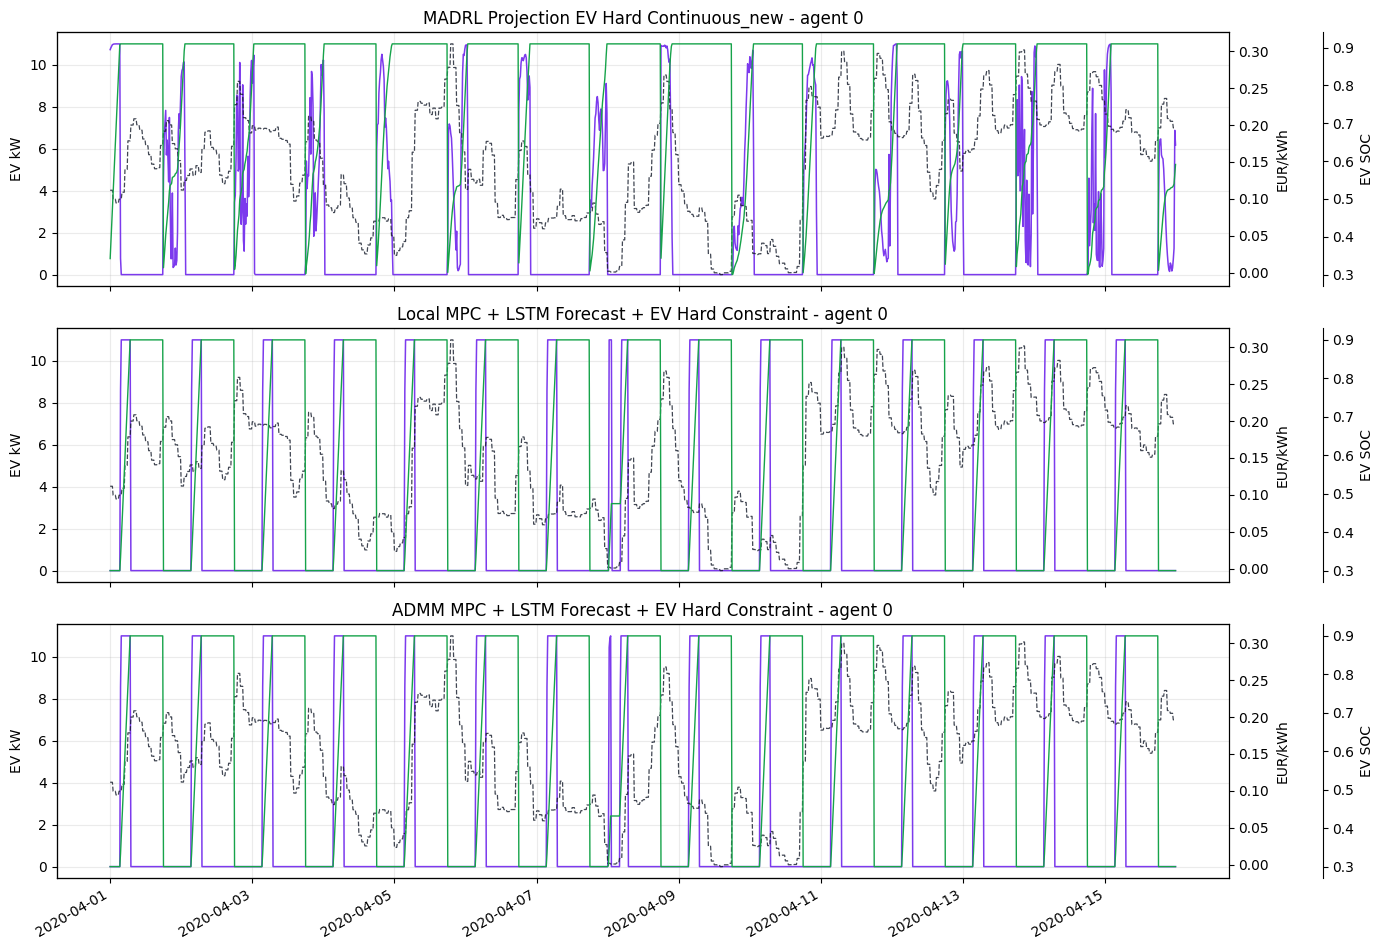

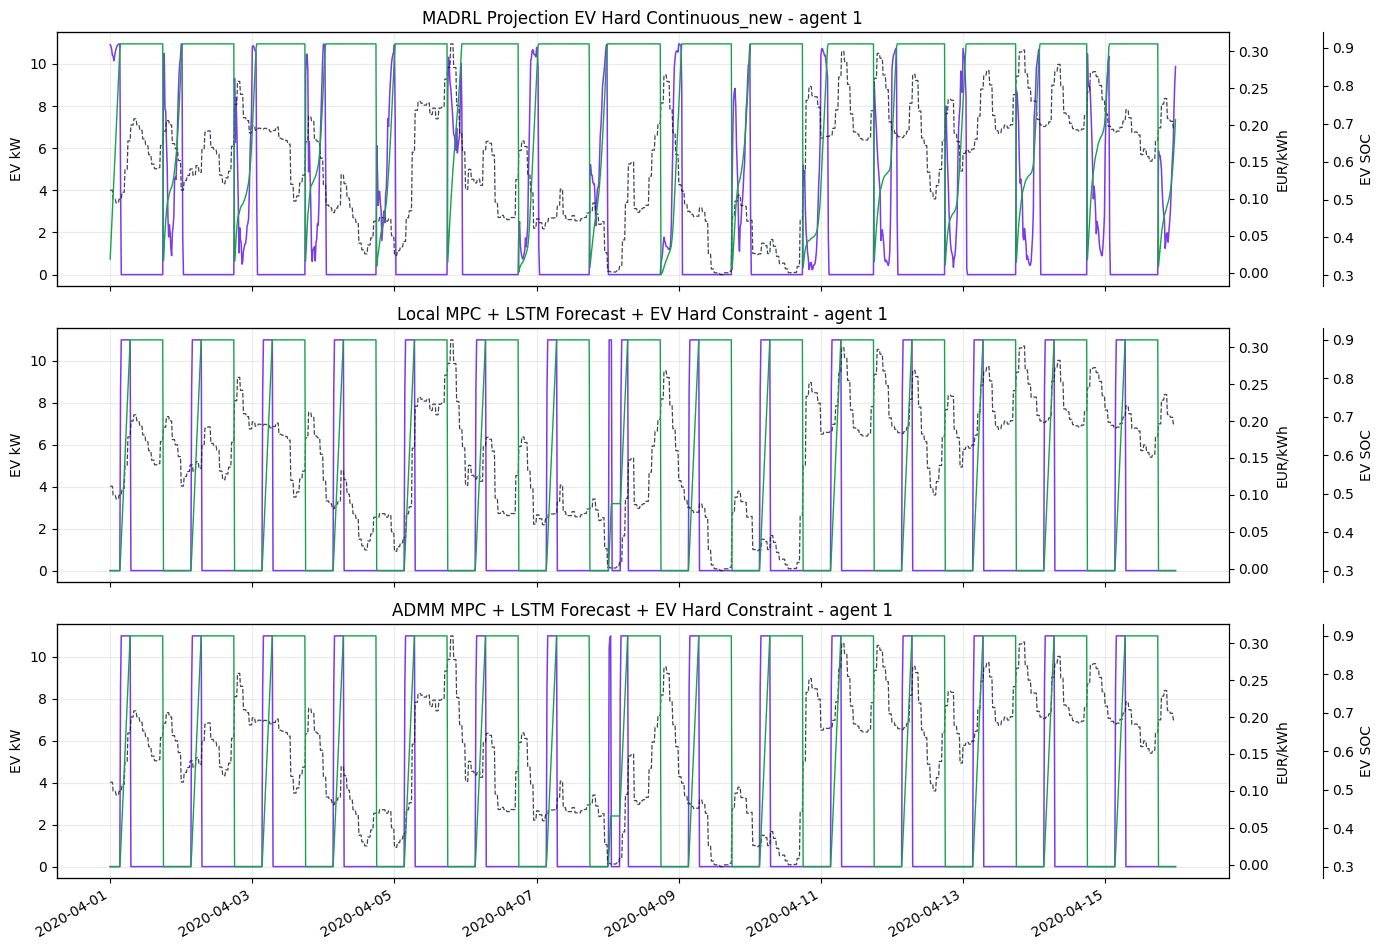

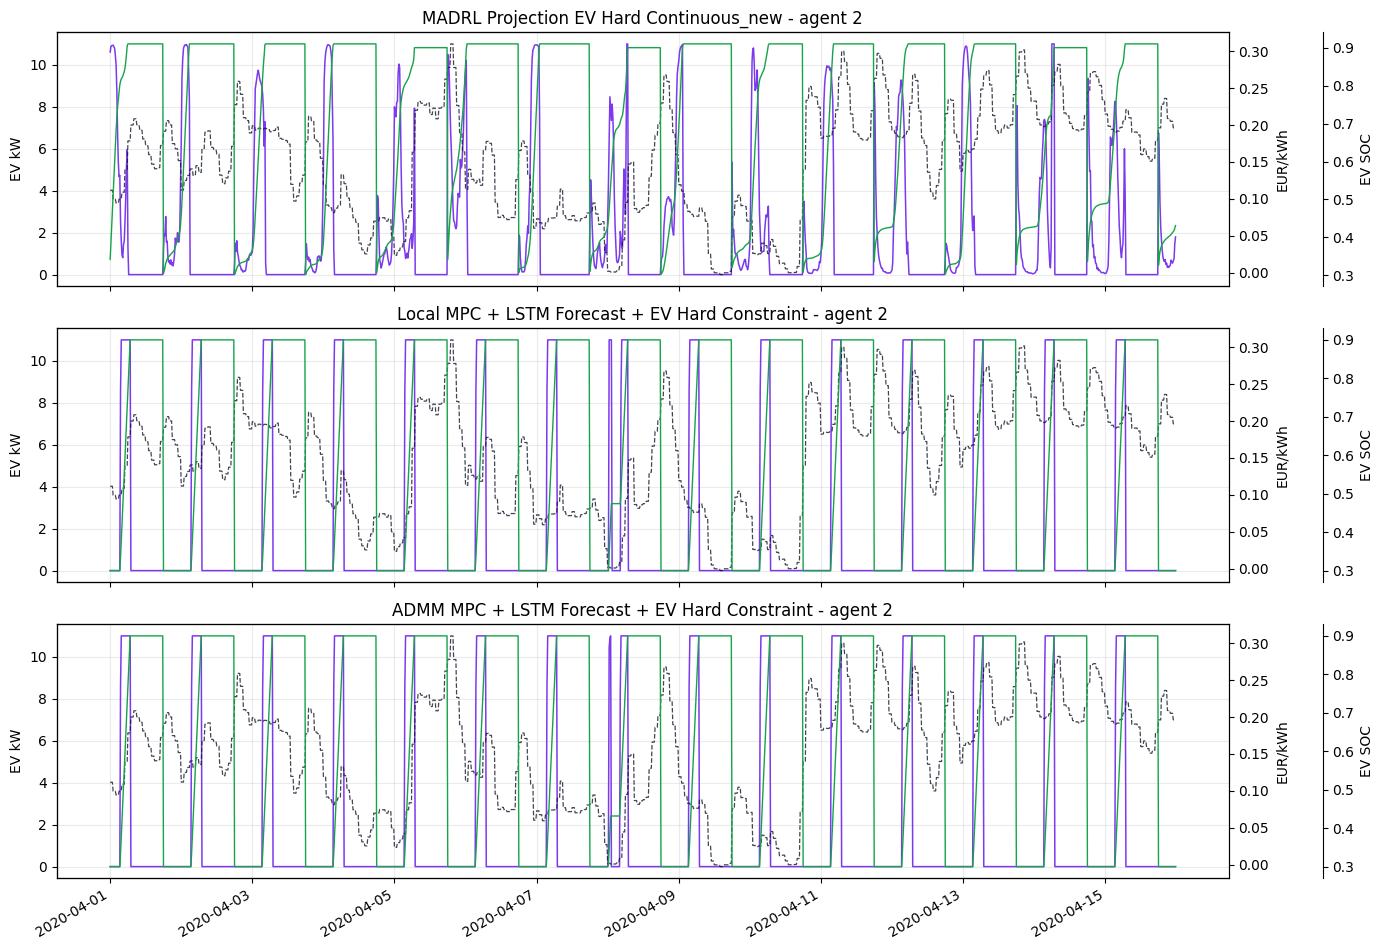

## 9. Training curve and reward summary

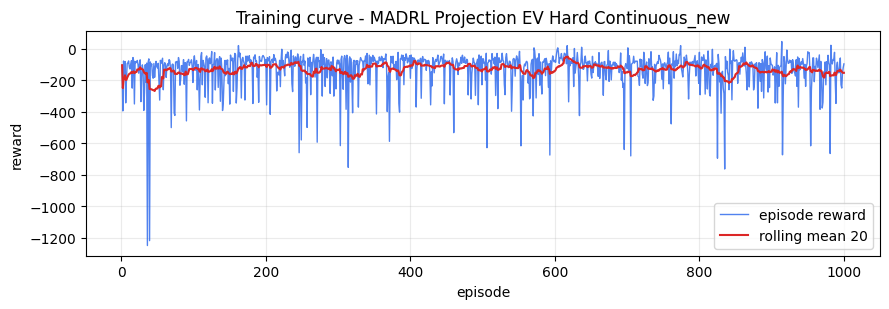

,scheme,episodes,reward_first,reward_last,reward_max,reward_mean,reward_tail20_mean,figure
0,MADRL Projection EV Hard Continuous_new,1000,-104.012245,-95.464539,46.829819,-130.742916,-152.068819,artifacts\runs\madrl_traindays_7\figures\ev_ba...


## 10. Battery clipped ratio / raw action vs projected action

,scheme,source,agent_id,clipped_ratio,clipped_count,inferred_pmax_kw,action_gap_abs_mean,action_gap_min,action_gap_max
0,MADRL Projection EV Hard Continuous_new,inferred_from_e_bat_near_limit,0,0.025694,37,50.000000,NaN,NaN,NaN
1,MADRL Projection EV Hard Continuous_new,inferred_from_e_bat_near_limit,1,0.004861,7,49.999702,NaN,NaN,NaN
2,MADRL Projection EV Hard Continuous_new,inferred_from_e_bat_near_limit,2,0.024306,35,49.999329,NaN,NaN,NaN


# Saved batch outputs

,table_dir,figure_dir
0,artifacts\runs\madrl_traindays_7\tables\ev_bat...,artifacts\runs\madrl_traindays_7\figures\ev_ba...


In [11]:
from pathlib import Path
# Batch EV MADRL vs MPC analysis
# Edit only these two variables for a new analysis run.
analysis_run_dir = Path("artifacts/runs/madrl_traindays_7")
selected_schemes = [
    "madrl_projection_safe_EV_hard_Continuous_new",
]

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ANALYSIS_OUT = analysis_run_dir / "figures" / "ev_batch_compare"
ANALYSIS_OUT.mkdir(parents=True, exist_ok=True)
TABLE_OUT = analysis_run_dir / "tables" / "ev_batch_compare"
TABLE_OUT.mkdir(parents=True, exist_ok=True)
RUN_CONFIG_PATH = analysis_run_dir / "config.json"
RUN_CONFIG = json.loads(RUN_CONFIG_PATH.read_text(encoding="utf-8")) if RUN_CONFIG_PATH.exists() else {}
ENV_CONFIG = RUN_CONFIG.get("env", {})

SCHEME_RECORDS = {
    "madrl_base_EV_hard": {"mode": "lstm", "controller": "MADRL_BASE_EV_HARD", "train_scheme": "madrl_base_EV_hard", "kind": "hard", "label": "MADRL Base EV Hard"},
    "madrl_projection_safe_EV_hard": {"mode": "lstm", "controller": "MADRL_PROJECTION_EV_HARD", "train_scheme": "madrl_projection_safe_EV_hard", "kind": "hard", "label": "MADRL Projection EV Hard"},
    "madrl_base_EV_soft_progress": {"mode": "lstm", "controller": "MADRL_BASE_PROGRESS", "train_scheme": "madrl_base_EV_soft_progress", "kind": "soft", "label": "MADRL Base EV Soft Progress"},
    "madrl_projection_safe_EV_soft": {"mode": "lstm", "controller": "MADRL_PROJECTION", "train_scheme": "madrl_projection_safe", "kind": "soft", "label": "MADRL Projection EV Soft"},
    "madrl_projection_safe_EV_hard_costweight": {"mode": "lstm","controller": "MADRL_PROJECTION_EV_HARD_CostWeight","train_scheme": "madrl_projection_safe_EV_hard_costweight","kind": "hard","label": "MADRL Projection EV Hard CostWeight",},
    "madrl_projection_safe_EV_hard_100P": {"mode": "lstm","controller": "MADRL_PROJECTION_EV_HARD_100P","train_scheme": "madrl_projection_safe_EV_hard_100P","kind": "hard","label": "MADRL Projection EV Hard 100P",},
    "madrl_projection_safe_EV_hard_Continuous2": {"mode": "lstm","controller": "MADRL_PROJECTION_EV_HARD_Continuous2","train_scheme": "madrl_projection_safe_EV_hard_Continuous2","kind": "hard","label": "MADRL Projection EV Hard Continuous2",},
"madrl_base_EV_soft_progress_continuous": {"mode": "lstm","controller": "MADRL_BASE_PROGRESS_CONTINUOUS","train_scheme": "madrl_base_EV_soft_progress_continuous","kind": "soft","label": "MADRL Base EV Soft Progress Continuous",},
    "madrl_projection_safe_Continuous_Progress": {
    "mode": "lstm",
    "controller": "madrl_projection_safe_Continuous_Progress",
    "train_scheme": "madrl_projection_safe_Continuous_Progress",
    "kind": "soft",
    "label": "MADRL Projection EV Soft Continuous Progress",
},
"madrl_projection_safe_EV_eme": {
    "mode": "lstm",
    "controller": "MADRL_PROJECTION_EV_EME",
    "train_scheme": "madrl_projection_safe_EV_eme",
    "kind": "emergency",
    "label": "MADRL Projection EV Emergency",
},
 "madrl_projection_safe_EV_hard_Continuous_new": {"mode": "lstm","controller": "MADRL_PROJECTION_EV_HARD_Continuous_new","train_scheme": "madrl_projection_safe_EV_hard_Continuous_new","kind": "hard","label": "MADRL Projection EV Hard Continuous_new",},
}

MPC_BASELINES = {
    "hard": [
        {"mode": "lstm", "controller": "local_mpc_lstm_EV_hard", "train_scheme": None, "kind": "hard", "label": "Local MPC + LSTM Forecast + EV Hard Constraint"},
        {"mode": "lstm", "controller": "admm_mpc_lstm_EV_hard", "train_scheme": None, "kind": "hard", "label": "ADMM MPC + LSTM Forecast + EV Hard Constraint"},
    ],
    "soft": [
        {"mode": "lstm", "controller": "local_mpc_lstm_EV_soft", "train_scheme": None, "kind": "soft", "label": "Local MPC + LSTM Forecast + EV soft"},
        {"mode": "lstm", "controller": "admm_mpc_lstm_EV_soft", "train_scheme": None, "kind": "soft", "label": "ADMM MPC + LSTM Forecast + EV soft"},
    ],
    "emergency": [
    {"mode": "lstm","controller": "local_mpc_lstm_EV_eme","train_scheme": None,"kind": "emergency","label": "Local MPC + LSTM Forecast + EV Emergency"},
    {"mode": "lstm","controller": "admm_mpc_lstm_EV_eme","train_scheme": None,"kind": "emergency","label": "ADMM MPC + LSTM Forecast + EV Emergency"},
],
}

def _record_dir(spec):
    return analysis_run_dir / "results" / spec["mode"] / spec["controller"] / "record"

def _load_record(spec):
    root = _record_dir(spec)
    step_path, agent_path = root / "step.parquet", root / "agent.parquet"
    if not step_path.exists() or not agent_path.exists():
        return None
    step = pd.read_parquet(step_path).copy()
    agent = pd.read_parquet(agent_path).copy()
    meta_path = root / "meta.json"
    meta = json.loads(meta_path.read_text(encoding="utf-8")) if meta_path.exists() else {}
    for frame in (step, agent):
        if "timestamp" in frame.columns:
            frame["timestamp"] = pd.to_datetime(frame["timestamp"])
    return {"spec": spec, "step": step, "agent": agent, "record_dir": root, "meta": meta}

def _scenario_records(scheme):
    if scheme not in SCHEME_RECORDS:
        raise KeyError(f"Unknown scheme {scheme!r}. Add it to SCHEME_RECORDS at the top of this cell.")
    main = SCHEME_RECORDS[scheme]
    return [main, *MPC_BASELINES.get(main["kind"], [])]

def _loaded_scenario(scheme):
    records = []
    for spec in _scenario_records(scheme):
        item = _load_record(spec)
        if item is None:
            print(f"Skip missing record: {spec['label']} -> {_record_dir(spec)}")
        else:
            records.append(item)
    return records

def _price_join(agent, step):
    price_col = "import_price" if "import_price" in step.columns else "wholesale_price"
    keys = [key for key in ["episode_idx", "step", "timestamp"] if key in agent.columns and key in step.columns]
    price = step[keys + [price_col]].drop_duplicates(keys).rename(columns={price_col: "price_eur_per_kwh"})
    return agent.merge(price, on=keys, how="left")

def _cost_row(item):
    spec, step, agent = item["spec"], item["step"], item["agent"]
    row = {"scheme": spec["label"], "controller": spec["controller"], "type": spec["kind"]}
    battery_cost = -agent["storage_profit_eur"].astype(float)
    ev_cost = agent["ev_charging_cost_eur"].astype(float) if "ev_charging_cost_eur" in agent.columns else pd.Series(0.0, index=agent.index)
    row["total_cost_eur"] = float(step["total_eur"].astype(float).sum()) if "total_eur" in step.columns else float(battery_cost.sum() + ev_cost.sum())
    row["ev_charging_cost_all_agents_eur"] = float(ev_cost.sum())
    row["battery_cost_all_agents_eur"] = float(battery_cost.sum())
    dt_hours = float(item.get("meta", {}).get("dt_hours", 0.25))
    requested = agent["ev_charge_kw_requested"].astype(float) if "ev_charge_kw_requested" in agent.columns else agent["ev_charge_kw"].astype(float)
    executed = agent["ev_charge_kw_executed"].astype(float) if "ev_charge_kw_executed" in agent.columns else agent["ev_charge_kw"].astype(float)
    clipped = agent["ev_charge_kw_clipped"].astype(float) if "ev_charge_kw_clipped" in agent.columns else (requested - executed).clip(lower=0.0)
    row["total_ev_charge_requested_kwh"] = float((requested.clip(lower=0.0) * dt_hours).sum())
    row["total_ev_charge_executed_kwh"] = float((executed.clip(lower=0.0) * dt_hours).sum())
    row["total_ev_charge_clipped_kwh"] = float((clipped.clip(lower=0.0) * dt_hours).sum())
    for agent_id, frame in agent.groupby("agent_id", sort=True):
        idx = int(agent_id)
        row[f"ev_charging_cost_agent_{idx}_eur"] = float(frame.get("ev_charging_cost_eur", pd.Series(0.0, index=frame.index)).astype(float).sum())
        row[f"battery_cost_agent_{idx}_eur"] = float((-frame["storage_profit_eur"].astype(float)).sum())
    return row

def _env_value(name, fallback):
    return ENV_CONFIG.get(name, fallback)

def _ev_capacity_for_agent(agent_id):
    values = _env_value("ev_capacity_kwh", [60.0, 60.0, 60.0])
    if not isinstance(values, (list, tuple)):
        values = [values]
    return float(values[int(agent_id)] if int(agent_id) < len(values) else values[-1])

def _ev_session_rows(item):
    spec, agent, meta = item["spec"], item["agent"].copy(), item["meta"]
    required = float(_env_value("ev_departure_soc_req", meta.get("ev_departure_soc_req", 0.90)))
    arrival_soc = float(_env_value("ev_arrival_soc", 0.30))
    efficiency = max(float(_env_value("ev_efficiency", 0.95)), 1e-9)
    dt_hours = float(meta.get("dt_hours", _env_value("dt_hours", 0.25)))
    episode_steps = int(_env_value("episode_steps", 96))
    arrival_step = int(_env_value("ev_arrival_step", 72)) % episode_steps
    departure_step = int(_env_value("ev_departure_step", meta.get("ev_departure_step", 28))) % episode_steps
    if not {"episode_idx", "step", "agent_id", "ev_charge_kw", "ev_soc"}.issubset(agent.columns):
        return []
    agent["daily_step"] = agent["step"].astype(int) % episode_steps
    episodes = set(int(value) for value in agent["episode_idx"].unique())
    cross_midnight = arrival_step > departure_step
    rows = []
    for start_episode in sorted(episodes):
        end_episode = start_episode + 1 if cross_midnight else start_episode
        if end_episode not in episodes:
            continue
        if cross_midnight:
            session_mask = ((agent["episode_idx"].astype(int) == start_episode) & (agent["daily_step"] >= arrival_step)) | ((agent["episode_idx"].astype(int) == end_episode) & (agent["daily_step"] < departure_step))
        else:
            session_mask = (agent["episode_idx"].astype(int) == start_episode) & (agent["daily_step"] >= arrival_step) & (agent["daily_step"] < departure_step)
        departure_mask = (agent["episode_idx"].astype(int) == end_episode) & (agent["daily_step"] == departure_step)
        for agent_id, frame in agent.loc[session_mask].groupby("agent_id", sort=True):
            departure = agent.loc[departure_mask & (agent["agent_id"].astype(int) == int(agent_id))]
            if frame.empty or departure.empty:
                continue
            theoretical = max(0.0, required - arrival_soc) * _ev_capacity_for_agent(agent_id) / efficiency
            energy = float(frame["ev_charge_kw"].astype(float).clip(lower=0.0).sum() * dt_hours)
            cost = float(frame["ev_charging_cost_eur"].astype(float).sum()) if "ev_charging_cost_eur" in frame.columns else 0.0
            dep_soc = float(departure["ev_soc"].astype(float).iloc[0])
            dep_gap = float(departure["ev_departure_gap"].astype(float).iloc[0]) if "ev_departure_gap" in departure.columns else max(0.0, required - dep_soc)
            rows.append({"scheme": spec["label"], "controller": spec["controller"], "type": spec["kind"], "agent_id": int(agent_id), "session_start_episode_idx": int(start_episode), "session_end_episode_idx": int(end_episode), "ev_session_energy_kwh": energy, "ev_session_cost_eur": cost, "departure_soc": dep_soc, "required_soc": required, "departure_gap": dep_gap, "theoretical_minimum_energy_kwh": theoretical, "actual_theoretical_ratio": energy / theoretical if theoretical > 1e-9 else np.nan})
    return rows

def _ev_session_summary(item):
    rows = _ev_session_rows(item)
    if not rows:
        return pd.DataFrame()
    sessions = pd.DataFrame(rows)
    summary = sessions.groupby(["scheme", "controller", "type", "agent_id"], as_index=False).agg(session_count=("ev_session_energy_kwh", "count"), ev_session_energy_total_kwh=("ev_session_energy_kwh", "sum"), ev_session_energy_mean_kwh=("ev_session_energy_kwh", "mean"), ev_session_cost_total_eur=("ev_session_cost_eur", "sum"), ev_session_cost_mean_eur=("ev_session_cost_eur", "mean"), departure_soc_mean=("departure_soc", "mean"), departure_soc_min=("departure_soc", "min"), departure_gap_mean=("departure_gap", "mean"), departure_gap_max=("departure_gap", "max"), theoretical_minimum_energy_per_session_kwh=("theoretical_minimum_energy_kwh", "mean"), theoretical_minimum_energy_total_kwh=("theoretical_minimum_energy_kwh", "sum"))
    summary["actual_theoretical_ratio"] = summary["ev_session_energy_total_kwh"] / summary["theoretical_minimum_energy_total_kwh"].replace(0.0, np.nan)
    return summary

def _departure_rows(item):
    spec, agent = item["spec"], item["agent"]
    if spec["kind"] != "soft" or "ev_departure_gap" not in agent.columns:
        return []
    dep = agent.loc[agent["ev_departure_gap"].astype(float).abs() >= 0.0].copy()
    if "step" in dep.columns:
        dep = dep.loc[dep["step"] % 96 == 28]
    rows = []
    for agent_id, frame in dep.groupby("agent_id", sort=True):
        gap = frame["ev_departure_gap"].astype(float)
        soc = frame["ev_soc"].astype(float)
        rows.append({"scheme": spec["label"], "agent_id": int(agent_id), "departure_rows": int(len(frame)), "departure_soc_min": float(soc.min()) if len(soc) else np.nan, "departure_soc_mean": float(soc.mean()) if len(soc) else np.nan, "departure_gap_max": float(gap.max()) if len(gap) else np.nan, "departure_gap_mean": float(gap.mean()) if len(gap) else np.nan, "departure_success_ratio": float((gap <= 1e-6).mean()) if len(gap) else np.nan})
    return rows

def _correlation_rows(item):
    spec = item["spec"]
    data = _price_join(item["agent"], item["step"])
    rows = []
    for agent_id, frame in data.groupby("agent_id", sort=True):
        price = frame["price_eur_per_kwh"].astype(float)
        battery = frame["e_bat"].astype(float)
        ev = frame["ev_charge_kw"].astype(float) if "ev_charge_kw" in frame.columns else pd.Series(0.0, index=frame.index)
        charging = battery > 1e-6
        discharging = battery < -1e-6
        ev_charging = ev > 1e-6
        rows.append({"scheme": spec["label"], "controller": spec["controller"], "type": spec["kind"], "agent_id": int(agent_id), "battery_power_price_corr": float(battery.corr(price)) if battery.nunique() > 1 and price.nunique() > 1 else np.nan, "battery_avg_price_when_charging": float(price[charging].mean()) if charging.any() else np.nan, "battery_avg_price_when_discharging": float(price[discharging].mean()) if discharging.any() else np.nan, "ev_charge_price_corr": float(ev.corr(price)) if ev.nunique() > 1 and price.nunique() > 1 else np.nan, "ev_avg_price_when_charging": float(price[ev_charging].mean()) if ev_charging.any() else np.nan, "ev_charge_mean_kw": float(ev.mean())})
    return rows

def _reward_summary(spec):
    scheme = spec.get("train_scheme")
    if not scheme:
        return None
    path = analysis_run_dir / "tables" / f"madrl_reward_curves_{scheme}.csv"
    if not path.exists():
        return None
    rewards = pd.read_csv(path)
    value_col = "total_reward" if "total_reward" in rewards.columns else "reward"
    fig, ax = plt.subplots(figsize=(9, 3.2))
    ax.plot(rewards["episode"], rewards[value_col], color="#2563eb", linewidth=1.0, alpha=0.8, label="episode reward")
    ax.plot(rewards["episode"], rewards[value_col].rolling(20, min_periods=1).mean(), color="#dc2626", linewidth=1.5, label="rolling mean 20")
    ax.set_title(f"Training curve - {spec['label']}"); ax.set_xlabel("episode"); ax.set_ylabel("reward"); ax.grid(True, alpha=0.25); ax.legend(); fig.tight_layout()
    out = ANALYSIS_OUT / f"{scheme}_training_curve.png"
    fig.savefig(out, dpi=150)
    display(fig); plt.close(fig)
    return pd.DataFrame([{"scheme": spec["label"], "episodes": int(rewards["episode"].max()), "reward_first": float(rewards[value_col].iloc[0]), "reward_last": float(rewards[value_col].iloc[-1]), "reward_max": float(rewards[value_col].max()), "reward_mean": float(rewards[value_col].mean()), "reward_tail20_mean": float(rewards[value_col].tail(20).mean()), "figure": str(out)}])

def _action_projection_row(item):
    spec, agent = item["spec"], item["agent"]
    scheme = spec.get("train_scheme")
    path = analysis_run_dir / "tables" / f"{scheme}_battery_action_projection_summary.csv" if scheme else None
    if path and path.exists():
        frame = pd.read_csv(path); frame.insert(0, "scheme", spec["label"]); frame.insert(1, "source", "raw_vs_projected_trace"); return frame
    rows = []
    for agent_id, frame in agent.groupby("agent_id", sort=True):
        p = frame["e_bat"].astype(float).abs()
        pmax = float(p.max()) if len(p) else np.nan
        rows.append({"scheme": spec["label"], "source": "inferred_from_e_bat_near_limit", "agent_id": int(agent_id), "clipped_ratio": float((p >= 0.999 * pmax).mean()) if np.isfinite(pmax) and pmax > 0 else np.nan, "clipped_count": int((p >= 0.999 * pmax).sum()) if np.isfinite(pmax) and pmax > 0 else 0, "inferred_pmax_kw": pmax, "action_gap_abs_mean": np.nan, "action_gap_min": np.nan, "action_gap_max": np.nan})
    return pd.DataFrame(rows)

def _plot_agent_panel(records, agent_id, quantity):
    n = len(records)
    fig, axes = plt.subplots(n, 1, figsize=(14, max(3.2 * n, 4.2)), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, item in zip(axes, records):
        data = _price_join(item["agent"], item["step"])
        frame = data.loc[data["agent_id"] == agent_id].sort_values(["episode_idx", "step"])
        x = frame["timestamp"] if "timestamp" in frame.columns else np.arange(len(frame))
        price_ax = ax.twinx()
        if quantity == "battery":
            ax.plot(x, frame["e_bat"].astype(float), color="#2563eb", label="battery power [kW]", linewidth=1.1)
            soc_ax = ax.twinx(); soc_ax.spines["right"].set_position(("axes", 1.08)); soc_ax.plot(x, frame["soc"].astype(float), color="#16a34a", label="battery SOC", linewidth=1.0)
            ax.axhline(0.0, color="#64748b", linewidth=0.7); ax.set_ylabel("battery kW"); soc_ax.set_ylabel("SOC")
        else:
            ax.plot(x, frame["ev_charge_kw"].astype(float), color="#7c3aed", label="EV charge [kW]", linewidth=1.1)
            soc_ax = ax.twinx(); soc_ax.spines["right"].set_position(("axes", 1.08)); soc_ax.plot(x, frame["ev_soc"].astype(float), color="#16a34a", label="EV SOC", linewidth=1.0)
            ax.set_ylabel("EV kW"); soc_ax.set_ylabel("EV SOC")
        price_ax.plot(x, frame["price_eur_per_kwh"].astype(float), color="#111827", linestyle="--", linewidth=0.9, alpha=0.8, label="price"); price_ax.set_ylabel("EUR/kWh")
        ax.set_title(f"{item['spec']['label']} - agent {agent_id}"); ax.grid(True, alpha=0.25)
    fig.autofmt_xdate(); fig.tight_layout()
    out = ANALYSIS_OUT / f"{quantity}_agent_{agent_id}_{'_'.join([r['spec']['controller'] for r in records])}.png"
    fig.savefig(out, dpi=150)
    display(fig); plt.close(fig)
    return out

all_cost_rows, all_session_rows, all_corr_rows, all_departure_rows, all_action_rows, reward_rows = [], [], [], [], [], []
for scheme in selected_schemes:
    display(Markdown(f"# EV batch comparison: `{scheme}`"))
    records = _loaded_scenario(scheme)
    if not records:
        display(Markdown("No records found for this scheme.")); continue
    cost_table = pd.DataFrame([_cost_row(item) for item in records])
    session_table = pd.concat([_ev_session_summary(item) for item in records], ignore_index=True) if records else pd.DataFrame()
    corr_table = pd.DataFrame([row for item in records for row in _correlation_rows(item)])
    departure_table = pd.DataFrame([row for item in records for row in _departure_rows(item)])
    action_table = pd.concat([_action_projection_row(item) for item in records if item["spec"].get("train_scheme")], ignore_index=True) if records else pd.DataFrame()
    all_cost_rows.extend(cost_table.to_dict("records")); all_session_rows.extend(session_table.to_dict("records")); all_corr_rows.extend(corr_table.to_dict("records")); all_departure_rows.extend(departure_table.to_dict("records")); all_action_rows.extend(action_table.to_dict("records"))
    display(Markdown("## 1-3. Calendar-day total cost, EV charging cost, battery cost (00:00-24:00)")); display(cost_table)
    display(Markdown("## 3b. EV session cost summary (18:00-07:00, complete parking sessions only)")); display(session_table if not session_table.empty else pd.DataFrame([{"note": "No complete EV session found. Need consecutive eval episodes."}]))
    if not departure_table.empty:
        display(Markdown("## 4. Soft EV departure SOC")); display(departure_table)
    display(Markdown("## 5-6. Price correlation: battery and EV")); display(corr_table)
    display(Markdown("## 7. Battery power, SOC, and price"))
    for agent_id in sorted(records[0]["agent"]["agent_id"].unique()):
        _plot_agent_panel(records, int(agent_id), "battery")
    display(Markdown("## 8. EV charge power, SOC, and price"))
    for agent_id in sorted(records[0]["agent"]["agent_id"].unique()):
        _plot_agent_panel(records, int(agent_id), "ev")
    display(Markdown("## 9. Training curve and reward summary"))
    rs = _reward_summary(records[0]["spec"])
    if rs is None:
        display(Markdown("No MADRL reward curve CSV found for the selected main scheme."))
    else:
        reward_rows.extend(rs.to_dict("records")); display(rs)
    display(Markdown("## 10. Battery clipped ratio / raw action vs projected action")); display(action_table if not action_table.empty else pd.DataFrame([{"note": "No action projection summary available."}]))

summary_tables = {"cost_summary": pd.DataFrame(all_cost_rows), "ev_session_cost_summary": pd.DataFrame(all_session_rows), "price_correlation_summary": pd.DataFrame(all_corr_rows), "soft_departure_summary": pd.DataFrame(all_departure_rows), "reward_summary": pd.DataFrame(reward_rows), "battery_action_projection_summary": pd.DataFrame(all_action_rows)}
for name, frame in summary_tables.items():
    if not frame.empty:
        frame.to_csv(TABLE_OUT / f"{name}.csv", index=False)
display(Markdown("# Saved batch outputs")); display(pd.DataFrame([{"table_dir": str(TABLE_OUT), "figure_dir": str(ANALYSIS_OUT)}]))
